<a href="https://github.com/Rick2898/Series_tiempo_prom_movil-/blob/main/ACTIVIDAD_3/entrega3.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" 
    alt="Open In Colab"/>
</a>

# Regresion lineal en series de tiempo

## Carga de paquetes

In [1]:
import pandas as pd
import numpy as np
from statsmodels.sandbox.stats.runs import runstest_1samp # prueba de rachas de Wald y Wolfowitz
import statsmodels.api as sm # prueba de Box-Pierce y la modificación de Ljung-Box
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pylab as py
from scipy import stats
from datetime import datetime
from dateutil.relativedelta import relativedelta
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_arch

## Carga de datos

In [2]:
df_empleo= pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
df_empleo.head()
df_empleo.shape

(222, 4)

## Particion de datos entre entrenamiento y prueba

In [3]:
train_len = 216
train_td = df_empleo[["Ocupados"]][:train_len]
test_td  = df_empleo[["Ocupados"]][train_len:]

## Tendencia lineal

In [4]:
y = train_td["Ocupados"].values
x = np.linspace(1,train_td.shape[0],train_td.shape[0])
X = sm.add_constant(x)
lin = sm.OLS(y,X)
lin_t = lin.fit()
print(lin_t.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     5386.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          1.10e-153
Time:                        13:46:32   Log-Likelihood:                -1500.2
No. Observations:                 216   AIC:                             3004.
Df Residuals:                     214   BIC:                             3011.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6925.6150     34.477    200.879      0.0

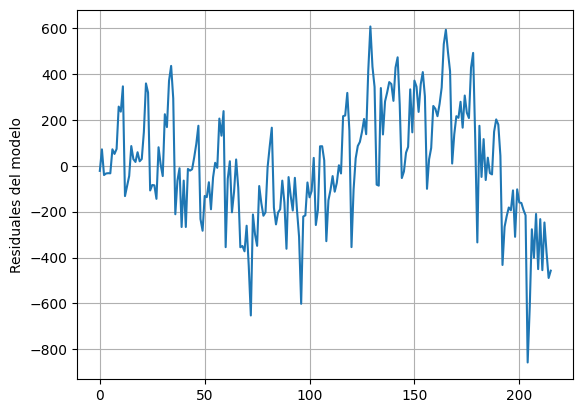

In [5]:
plt.ylabel("Residuales del modelo")
plt.plot(lin_t.resid)
plt.grid()

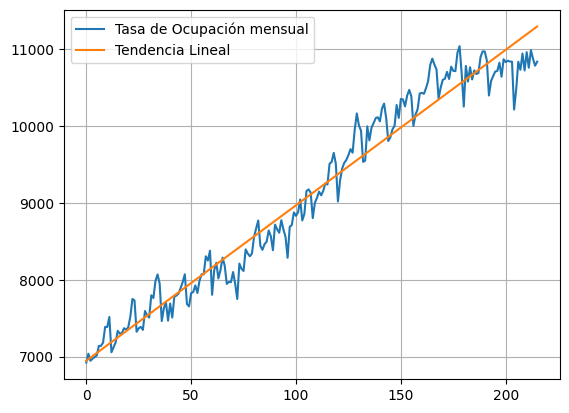

In [6]:
plt.plot(y,label="Tasa de Ocupación mensual")
plt.plot(lin_t.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

In [7]:
h=6
x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)
X_for= sm.add_constant(x_for)

In [8]:
dt = lin_t.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

   Point_forecast      lower_95      upper_95
0    11313.116341  10810.849071  11815.383612
1    11333.335242  10831.003977  11835.666506
2    11353.554142  10851.158304  11855.949979
3    11373.773042  10871.312053  11876.234030
4    11393.991942  10891.465223  11896.518660
5    11414.210842  10911.617816  11916.803868


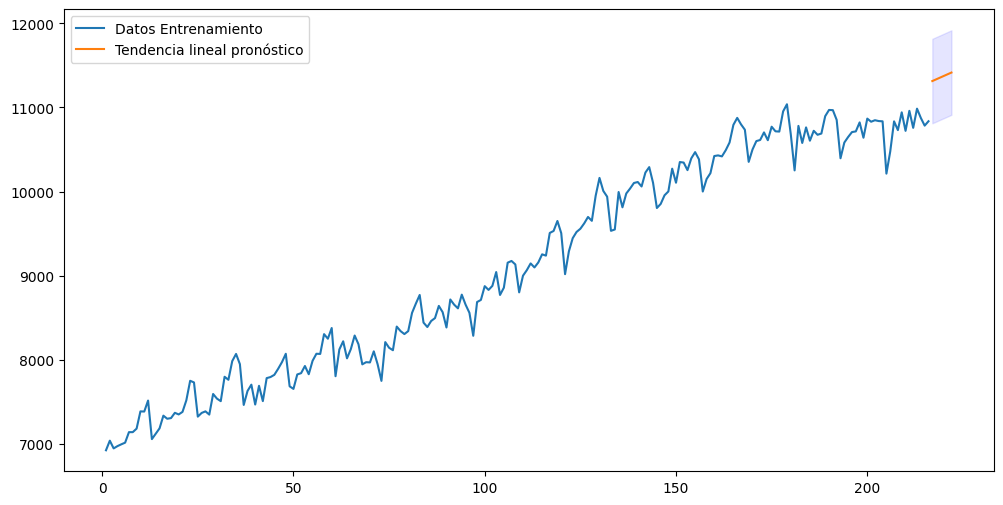

In [9]:
fig = plt.figure(figsize=(12, 6))
plt.plot(x,y,label="Datos Entrenamiento")
plt.plot(x_for,preds['Point_forecast'],label="Tendencia lineal pronóstico")
plt.fill_between(x_for ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

### Metricas

In [10]:
rmse_add = np.sqrt(mean_squared_error(
    test_td, preds['Point_forecast']
))
print(rmse_add)

725.5285275153046


## Tendencia cuadratica

In [11]:
y = train_td["Ocupados"]
train_td["x"] = np.linspace(1,train_td.shape[0],train_td.shape[0])
train_td["x2"] = train_td["x"]**2
X = sm.add_constant(train_td[["x","x2"]])
pol = sm.OLS(y,X)
pol_2 = pol.fit()
print(pol_2.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     2752.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          6.85e-153
Time:                        13:46:32   Log-Likelihood:                -1497.5
No. Observations:                 216   AIC:                             3001.
Df Residuals:                     213   BIC:                             3011.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6835.5053     51.482    132.774      0.0

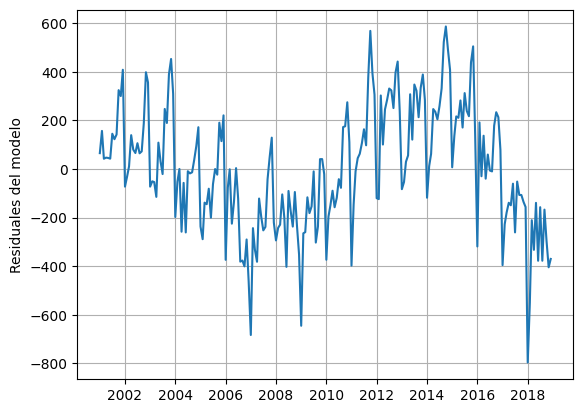

In [12]:
plt.ylabel("Residuales del modelo")
plt.plot(pol_2.resid)
plt.grid()

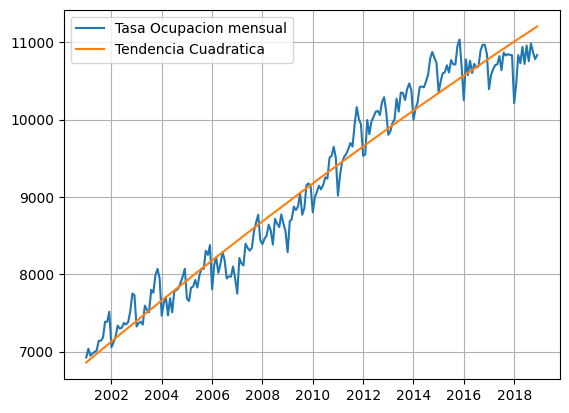

In [13]:
plt.plot(y,label="Tasa Ocupacion mensual")
plt.plot(pol_2.fittedvalues,label="Tendencia Cuadratica")
plt.legend()
plt.grid()
plt.show()

In [14]:
h=6
x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)
X_for= sm.add_constant(np.stack((x_for, x_for**2), axis=1))

In [15]:
dt = pol_2.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

   Point_forecast      lower_95      upper_95
0    11223.006575  10720.110033  11725.903118
1    11240.733961  10737.453096  11744.014826
2    11258.438489  10754.761188  11762.115790
3    11276.120159  10772.034093  11780.206225
4    11293.778971  10789.271596  11798.286346
5    11311.414925  10806.473482  11816.356368


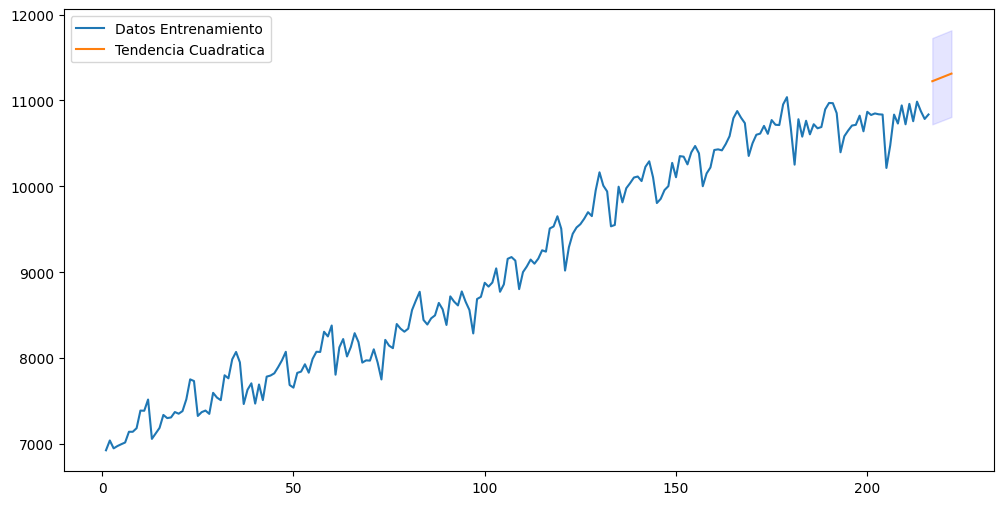

In [16]:
fig = plt.figure(figsize=(12, 6))
plt.plot(x,y,label="Datos Entrenamiento")
plt.plot(x_for,preds['Point_forecast'],label="Tendencia Cuadratica")
plt.fill_between(x_for ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

## Metricas

In [17]:
rmse_add = np.sqrt(mean_squared_error(
    test_td, preds['Point_forecast']
))
print(rmse_add)

632.4766573075538


## Tendencia cubica

In [18]:
y = train_td["Ocupados"]
train_td["x"] = np.linspace(1,train_td.shape[0],train_td.shape[0])
train_td["x2"] = train_td["x"]**2
train_td["x3"] = train_td["x"]**3
X = sm.add_constant(train_td[["x","x2","x3"]])
pol = sm.OLS(y,X)
pol_3 = pol.fit()
print(pol_3.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     2949.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          1.62e-172
Time:                        13:46:33   Log-Likelihood:                -1447.3
No. Observations:                 216   AIC:                             2903.
Df Residuals:                     212   BIC:                             2916.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7247.0943     54.981    131.810      0.0

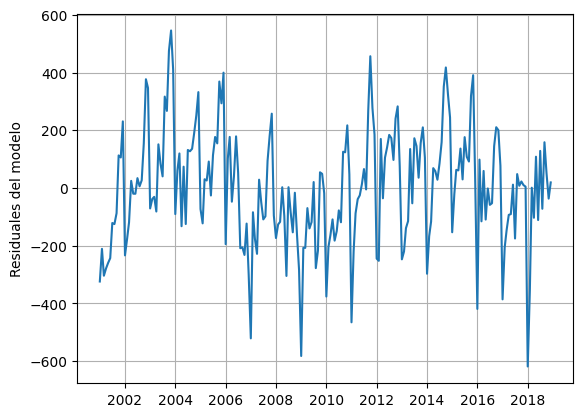

In [19]:
plt.ylabel("Residuales del modelo")
plt.plot(pol_3.resid)
plt.grid()

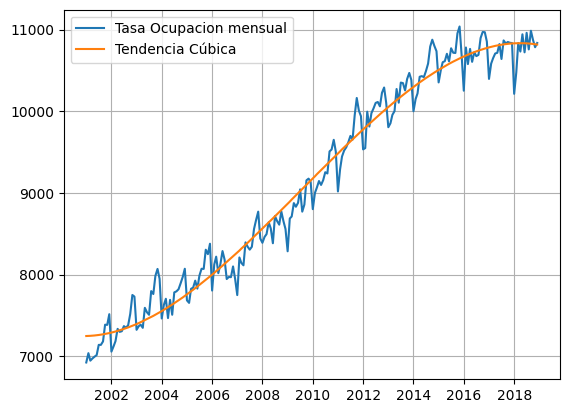

In [20]:
plt.plot(y,label="Tasa Ocupacion mensual")
plt.plot(pol_3.fittedvalues,label="Tendencia Cúbica")
plt.legend()
plt.grid()
plt.show()

In [21]:
h=6
x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)
X_for= sm.add_constant(np.stack((x_for, x_for**2, x_for**3), axis=1))

In [22]:
dt = pol_3.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

   Point_forecast      lower_95      upper_95
0    10811.417558  10405.366847  11217.468269
1    10806.384261  10399.300100  11213.468423
2    10800.806072  10392.623991  11208.988153
3    10794.678224  10385.331151  11204.025296
4    10787.995948  10377.414174  11198.577723
5    10780.754479  10368.865618  11192.643339


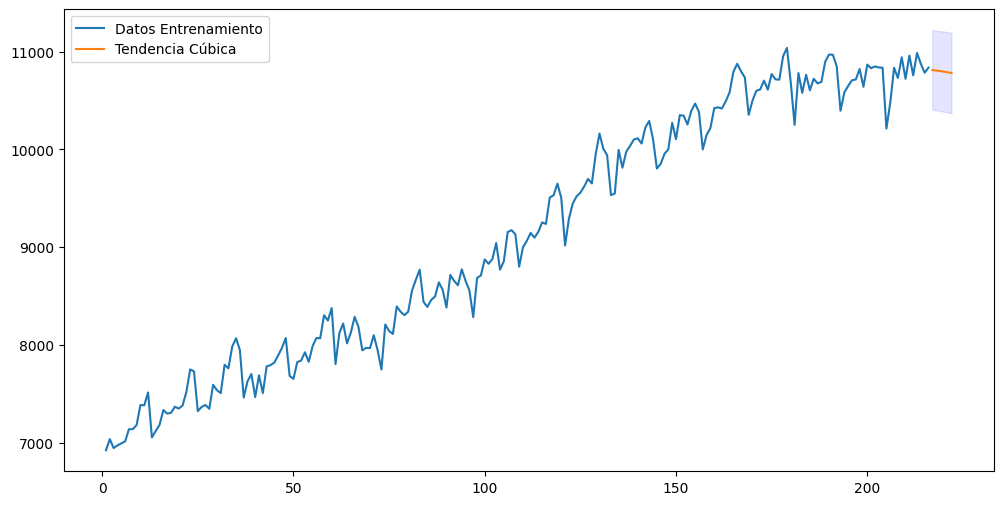

In [23]:
fig = plt.figure(figsize=(12, 6))
plt.plot(x,y,label="Datos Entrenamiento")
plt.plot(x_for,preds['Point_forecast'],label="Tendencia Cúbica")
plt.fill_between(x_for ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

## Metricas

In [24]:
rmse_add = np.sqrt(mean_squared_error(
    test_td, preds['Point_forecast']
))
print(rmse_add)

238.72205796222684


## Estacionalidad - dummies

In [25]:
month_dummies = pd.get_dummies(train_td.index.month,drop_first=True, dtype=float).set_index(train_td.index)

y = train_td["Ocupados"]
X = sm.add_constant(month_dummies)
sea = sm.OLS(y,X)
season = sea.fit()
print(season.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                 -0.032
Method:                 Least Squares   F-statistic:                    0.3897
Date:                Thu, 04 Jun 2026   Prob (F-statistic):              0.959
Time:                        13:46:34   Log-Likelihood:                -1850.6
No. Observations:                 216   AIC:                             3725.
Df Residuals:                     204   BIC:                             3766.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8724.5387    308.558     28.275      0.0

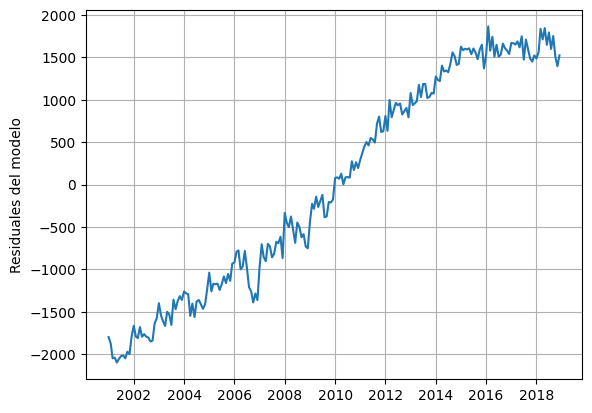

In [26]:
plt.ylabel("Residuales del modelo")
plt.plot(season.resid)
plt.grid()

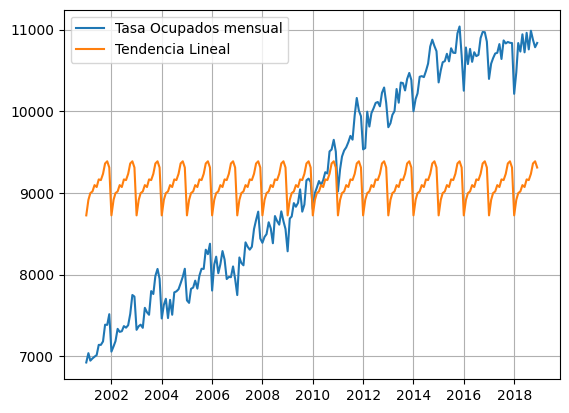

In [27]:
plt.plot(y,label="Tasa Ocupados mensual")
plt.plot(season.fittedvalues,label="Tendencia Lineal")
plt.legend()
plt.grid()
plt.show()

In [28]:
range_dates = pd.date_range(train_td.index[-1]+ relativedelta(months=1), periods=6,freq='MS')

x_for = pd.get_dummies(range_dates.month,drop_first=True, dtype=float)
X_for= sm.add_constant(x_for)

In [29]:
# Alinear columnas con las del entrenamiento
x_for = x_for.reindex(columns=month_dummies.columns, fill_value=0)

# Agregar constante
X_for = sm.add_constant(x_for, has_constant="add")

# Predicción
dt = season.get_prediction(X_for).summary_frame(alpha=0.05)

preds = pd.DataFrame({
    "Point_forecast": dt["mean"].values,
    "lower_95": dt["obs_ci_lower"].values,
    "upper_95": dt["obs_ci_upper"].values
}, index=range_dates)

print(preds)

            Point_forecast     lower_95      upper_95
2019-01-01     8724.538722  6072.708767  11376.368678
2019-02-01     8914.544389  6262.714433  11566.374344
2019-03-01     8997.218333  6345.388378  11649.048289
2019-04-01     9017.681722  6365.851767  11669.511678
2019-05-01     9095.089000  6443.259045  11746.918955
2019-06-01     9071.789000  6419.959045  11723.618955


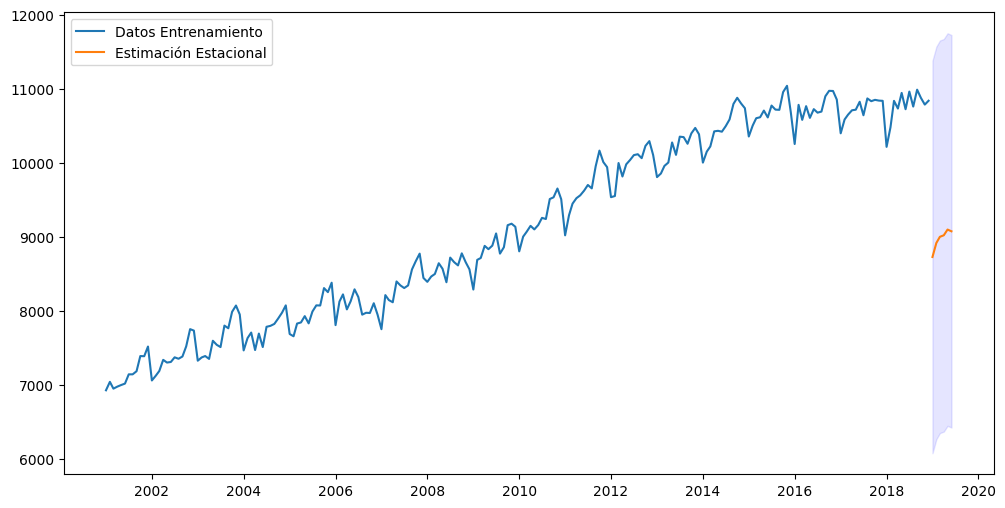

In [30]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Estimación Estacional")
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()


In [31]:
rmse_add = np.sqrt(mean_squared_error(
    test_td, preds['Point_forecast']
))
print(rmse_add)

1685.7662214902116


## Tendencia cubica + Estacionalidad

In [32]:
y = train_td["Ocupados"]
train_td["x"] = np.linspace(1,train_td.shape[0],train_td.shape[0])
train_td["x2"] = train_td["x"]**2
train_td["x3"] = train_td["x"]**3

month_dummies = pd.get_dummies(train_td.index.month,drop_first=True, dtype=float).set_index(train_td.index)
X = sm.add_constant( pd.concat([train_td[["x","x2","x3"]],month_dummies],axis=1) )

season_pol3 = sm.OLS(y,X)
season_pol_3 = season_pol3.fit()
print(season_pol_3.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     1096.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          2.56e-181
Time:                        13:46:35   Log-Likelihood:                -1383.2
No. Observations:                 216   AIC:                             2796.
Df Residuals:                     201   BIC:                             2847.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6980.7137     53.194    131.232      0.0

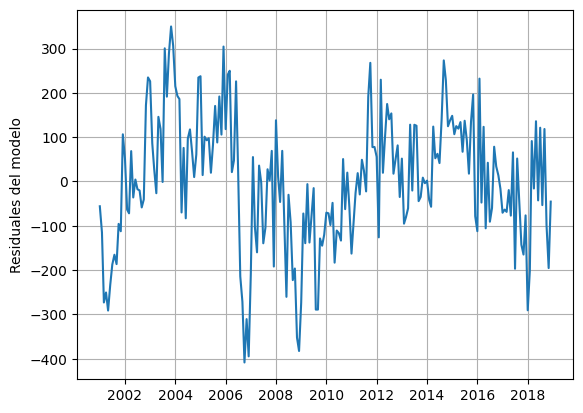

In [33]:
plt.ylabel("Residuales del modelo")
plt.plot(season_pol_3.resid)
plt.grid()

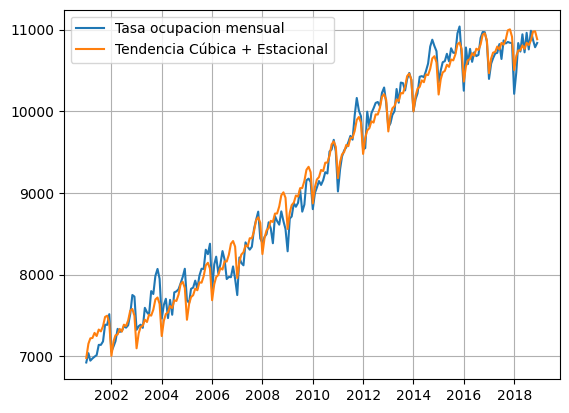

In [34]:
plt.plot(y,label="Tasa ocupacion mensual")
plt.plot(season_pol_3.fittedvalues,label="Tendencia Cúbica + Estacional")
plt.legend()
plt.grid()
plt.show()

In [35]:
h=6
x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)
x_for_all = pd.DataFrame(np.stack((x_for, x_for**2, x_for**3),axis=1),columns=["x","x2","x3"] )

range_dates = pd.date_range(train_td.index[-1]+ relativedelta(months=1), periods=h,freq='MS')
x_for_dummies = pd.get_dummies(range_dates.month,drop_first=True, dtype=float)

# Muy importante: alinear con las columnas de entrenamiento
x_for_dummies = x_for_dummies.reindex(
    columns=month_dummies.columns,
    fill_value=0
)

# Unir tendencia + estacionalidad
X_for = pd.concat(
    [x_for_all, x_for_dummies.reset_index(drop=True)],
    axis=1
)

# Agregar constante
X_for = sm.add_constant(X_for, has_constant="add")
X_for

,const,x,x2,x3,2,3,4,5,6,7,8,9,10,11,12
0,1.0,217.0,47089.0,10218313.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
1,1.0,218.0,47524.0,10360232.0,1.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
2,1.0,219.0,47961.0,10503459.0,0.0,1.0,0.0,0.0,0.0,0,0,0,0,0,0
3,1.0,220.0,48400.0,10648000.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0
4,1.0,221.0,48841.0,10793861.0,0.0,0.0,0.0,1.0,0.0,0,0,0,0,0,0
5,1.0,222.0,49284.0,10941048.0,0.0,0.0,0.0,0.0,1.0,0,0,0,0,0,0


In [36]:
dt = season_pol_3.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)

            Point_forecast      lower_95      upper_95
2019-01-01    10466.696419  10148.714218  10784.678619
2019-02-01    10633.804522  10315.146080  10952.462963
2019-03-01    10693.000988  10373.626992  11012.374984
2019-04-01    10689.406985  10369.276573  11009.537397
2019-05-01    10742.176957  10421.247701  11063.106213
2019-06-01    10693.659736  10371.887621  11015.431852


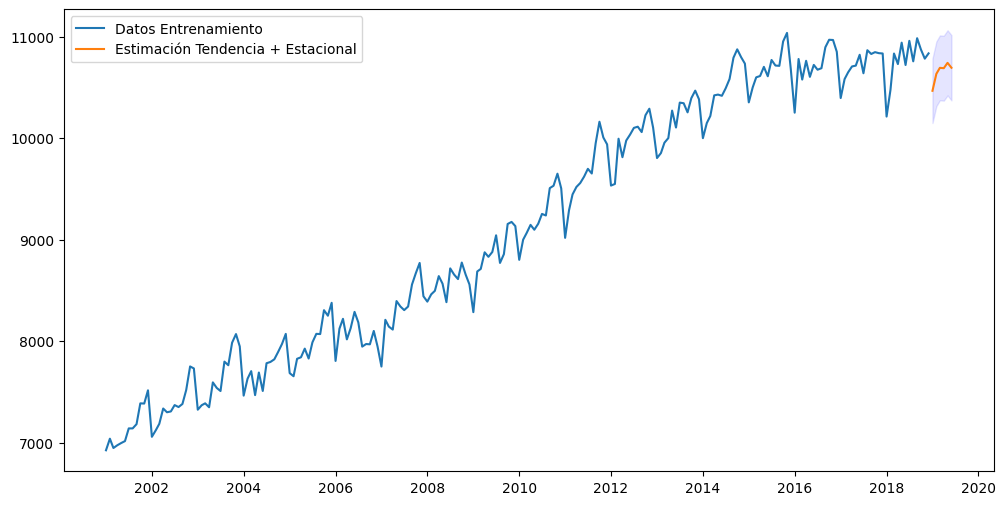

In [37]:
fig = plt.figure(figsize=(12, 6))
plt.plot(y.index,y,label="Datos Entrenamiento")
plt.plot(preds.index,preds['Point_forecast'],label="Estimación Tendencia + Estacional")
plt.fill_between(preds.index,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [38]:
rmse_add = np.sqrt(mean_squared_error(
    test_td, preds['Point_forecast']
))
print(rmse_add)

104.61370412228936


In [39]:
h=6
x_for= np.linspace((train_td.shape[0]+1),(train_td.shape[0]+h),h)
x_for_all = pd.DataFrame(np.stack((x_for, x_for**2, x_for**3),axis=1),columns=["x","x2","x3"] )

range_dates = pd.date_range(train_td.index[-1]+ relativedelta(months=1), periods=h,freq='MS')
x_for_dummies = pd.get_dummies(range_dates.month,drop_first=True, dtype=float)

# Muy importante: alinear con las columnas de entrenamiento
x_for_dummies = x_for_dummies.reindex(
    columns=month_dummies.columns,
    fill_value=0
)

# Unir tendencia + estacionalidad
X_for = pd.concat(
    [x_for_all, x_for_dummies.reset_index(drop=True)],
    axis=1
)

# Agregar constante
X_for = sm.add_constant(X_for, has_constant="add")
X_for

,const,x,x2,x3,2,3,4,5,6,7,8,9,10,11,12
0,1.0,217.0,47089.0,10218313.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
1,1.0,218.0,47524.0,10360232.0,1.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
2,1.0,219.0,47961.0,10503459.0,0.0,1.0,0.0,0.0,0.0,0,0,0,0,0,0
3,1.0,220.0,48400.0,10648000.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0
4,1.0,221.0,48841.0,10793861.0,0.0,0.0,0.0,1.0,0.0,0,0,0,0,0,0
5,1.0,222.0,49284.0,10941048.0,0.0,0.0,0.0,0.0,1.0,0,0,0,0,0,0


In [40]:
dt = season_pol_3.get_prediction(X_for).summary_frame(alpha = 0.05)
y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']
preds = pd.DataFrame(np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]))
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
preds.set_index(range_dates,inplace=True)
print(preds)

            Point_forecast      lower_95      upper_95
2019-01-01    10466.696419  10148.714218  10784.678619
2019-02-01    10633.804522  10315.146080  10952.462963
2019-03-01    10693.000988  10373.626992  11012.374984
2019-04-01    10689.406985  10369.276573  11009.537397
2019-05-01    10742.176957  10421.247701  11063.106213
2019-06-01    10693.659736  10371.887621  11015.431852


## Ya que encontramos el mejor modelo, volvemos a entrenar el modelo pero con train + test

In [41]:
td_full = pd.concat([train_td, test_td], axis=0)

td_full = td_full.sort_index()

In [42]:
y = td_full["Ocupados"]
td_full["x"] = np.linspace(1,td_full.shape[0],td_full.shape[0])
td_full["x2"] = td_full["x"]**2
td_full["x3"] = td_full["x"]**3

month_dummies = pd.get_dummies(td_full.index.month,drop_first=True, dtype=float).set_index(td_full.index)
X = sm.add_constant( pd.concat([td_full[["x","x2","x3"]],month_dummies],axis=1) )

season_pol3 = sm.OLS(y,X)
season_pol_3 = season_pol3.fit()
print(season_pol_3.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     1158.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          4.96e-188
Time:                        13:46:35   Log-Likelihood:                -1420.0
No. Observations:                 222   AIC:                             2870.
Df Residuals:                     207   BIC:                             2921.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6971.9175     51.941    134.228      0.0

## Regresión lineal

### Autocorrelación

In [43]:
# Residuos del modelo ajustado
residuos = season_pol_3.resid

# Quitar posibles valores nulos
residuos = residuos.dropna()

# Crear signos de los residuos
signo = residuos > 0

# Verificar cuántos positivos y negativos hay
print(signo.value_counts())

# Prueba de rachas
z_stat, p_value = runstest_1samp(signo, correction=False)

print("Estadístico Z:", z_stat)
print("p-valor:", p_value)

True     112
False    110
Name: count, dtype: int64
Estadístico Z: -5.3806640999852045
p-valor: 7.421155420013247e-08


Dado que el p-valor obtenido es menor que 0.05, se rechaza la hipótesis nula de aleatoriedad en los residuos. Por tanto, existe evidencia estadística de autocorrelación en los residuos del modelo

In [44]:
# prueba de Box-Pierce y la modificación de Ljung-Box
sm.stats.acorr_ljungbox(residuos, lags=[1], return_df=True,boxpierce=True ) # Se puede hacer para un solo lag.

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,86.348633,1.508528e-20,85.192178,2.707307e-20


Con el resultado anterior rechazamos la hipótesis nula de no autocorrelación para el primer rezago, lo ideal antes de tomar la decisión Es probar por lo menos los primeros 20 rezagos.

In [45]:
Resul_lb_bp = sm.stats.acorr_ljungbox(residuos, lags=range(1,21), return_df=True,boxpierce=True )
Resul_lb_bp["lb_ho"] = np.where(Resul_lb_bp['lb_pvalue']<0.05, 'rechazo_ho/hay_autocorr', 'no_rechazo_ho/no_hay_autocorr')
Resul_lb_bp["bp_ho"] = np.where(Resul_lb_bp['bp_pvalue']<0.05, 'rechazo_ho/hay_autocorr', 'no_rechazo_ho/no_hay_autocorr')

Resul_lb_bp

,lb_stat,lb_pvalue,bp_stat,bp_pvalue,lb_ho,bp_ho
1,86.348633,1.508528e-20,85.192178,2.707307e-20,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
2,155.169783,2.019807e-34,152.784379,6.657232e-34,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
3,210.756566,1.998343e-45,207.130386,1.214373e-44,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
4,242.507473,2.675675e-51,238.030822,2.463206e-50,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
5,262.850219,9.596852e-55,257.737857,1.201066e-53,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
6,279.813031,1.722767e-57,274.094854,2.884750e-56,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
7,291.667710,3.636541e-59,285.473230,7.632339e-58,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
8,301.043047,2.469799e-60,294.430025,6.308373e-59,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
9,313.165484,4.194617e-62,305.957163,1.421654e-60,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
10,320.933232,5.787015e-63,313.308782,2.380023e-61,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr


En el anterior data frame las columnas lb_ho y bp_ho nos permiten entender la decisión a tomar al usar las dos pruebas, en todos los rezagos parece presentar autocorrelacion, por lo tanto se puede concluir que la serie no parece comportarse como un ruido blanco, si presenta autocorrelación.

### Homoscedasticidad y Heteroscedasticidad

In [46]:
bp_test = het_breuschpagan(residuos, season_pol_3.model.exog)

bp_result = pd.Series(
    bp_test,
    index=[
        "LM statistic",
        "LM p-value",
        "F statistic",
        "F p-value"
    ]
)

print(bp_result)

LM statistic    33.937510
LM p-value       0.002106
F statistic      2.668211
F p-value        0.001319
dtype: float64


In [47]:
arch_test = het_arch(residuos, nlags=12)

arch_result = pd.Series(
    arch_test,
    index=[
        "LM statistic",
        "LM p-value",
        "F statistic",
        "F p-value"
    ]
)

print(arch_result)

LM statistic    6.200655e+01
LM p-value      9.699318e-09
F statistic     6.878283e+00
F p-value       2.444713e-10
dtype: float64


Para evaluar el supuesto de varianza constante en los residuos del modelo, se aplicaron las pruebas de Breusch-Pagan y ARCH. La prueba de Breusch-Pagan contrasta la hipótesis nula de homocedasticidad. Dado que ambos p-valores son menores que el nivel de significancia de 0.05, se rechaza la hipótesis nula de homocedasticidad. Por tanto, existe evidencia estadística de heterocedasticidad en los residuos del modelo. Adicionalmente, se aplicó la prueba ARCH con 12 rezagos, con el fin de identificar si la varianza de los residuos presenta dependencia temporal. Estos valores también son menores que 0.05, por lo que se rechaza la hipótesis nula de ausencia de efectos ARCH. En consecuencia, se evidencia que la varianza de los residuos no solo es heterocedástica, sino que además presenta comportamiento dependiente en el tiempo.

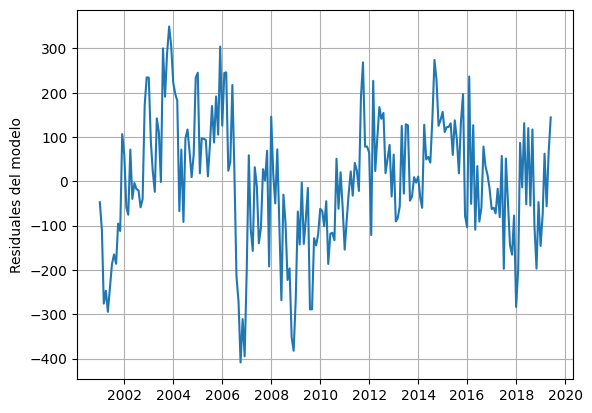

In [48]:
plt.ylabel("Residuales del modelo")
plt.plot(residuos)
plt.grid()

### Normalidad

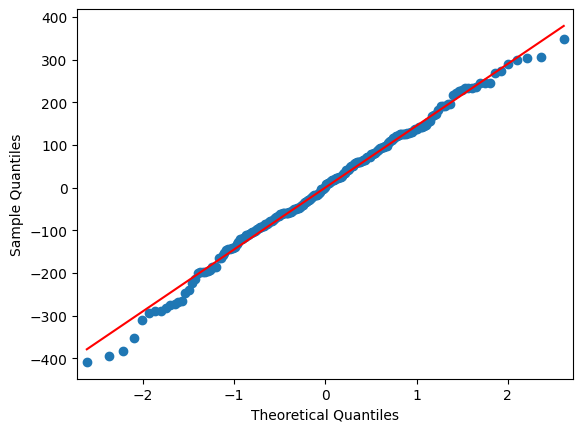

In [49]:
sm.qqplot(residuos, line ='s')
py.show()

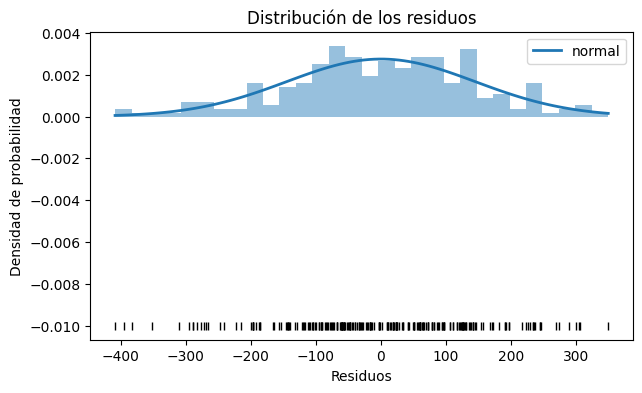

In [50]:
# Histograma + curva normal teórica
# ==============================================================================

# Valores de la media (mu) y desviación típica (sigma) de los datos
mu, sigma = stats.norm.fit(residuos)

# Valores teóricos de la normal en el rango observado
x_hat = np.linspace(min(residuos), max(residuos), num=100)
y_hat = stats.norm.pdf(x_hat, mu, sigma)

# Gráfico
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(x_hat, y_hat, linewidth=2, label='normal')
ax.hist(x=residuos, density=True, bins=30, color="#3182bd", alpha=0.5)
ax.plot(residuos, np.full_like(residuos, -0.01), '|k', markeredgewidth=1)
ax.set_title('Distribución de los residuos')
ax.set_xlabel('Residuos')
ax.set_ylabel('Densidad de probabilidad')
ax.legend();


In [51]:
stats.shapiro(residuos)


ShapiroResult(statistic=np.float64(0.992597646582586), pvalue=np.float64(0.32989485316184763))

In [52]:
stats.jarque_bera(residuos)

SignificanceResult(statistic=np.float64(1.9119126807417208), pvalue=np.float64(0.3844443090799362))

Para ambas pruebas, no se puede rechazar la hipótesis de que los datos provienen de una distribución normal.

Los residuos del modelo no presentan un comportamiento compatible con ruido blanco, debido a que se encontró evidencia estadística de autocorrelación y heterocedasticidad. Esto indica que el modelo no captura completamente la dinámica temporal de la serie y que aún existen patrones sistemáticos en los errores.